<a href="https://colab.research.google.com/github/akshayakp26/Predictive-Analytics-Lab-Exam-2.-/blob/main/PA_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/Lab_Exam_binary_classification_dataset.csv')
print(df.head())

   Feature1  Feature2 Target
0    1.7250       520    Yes
1    1.8875       428     No
2    1.6000       552    Yes
3    1.4250       500     No
4    1.7750       628     No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB


In [ ]:
df.describe()

,Feature1,Feature2
count,1020.000000,1020.000000
mean,11.436679,520.988235
std,313.061049,69.793442
min,1.250000,400.000000
25%,1.450000,464.000000
50%,1.637500,520.000000
75%,1.828125,584.000000
max,10000.000000,640.000000


In [ ]:
df.isnull().sum()

,0
Feature1,0
Feature2,0
Target,20


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Feature1,0
Feature2,0
Target,0


In [ ]:
df['Target'] = df['Target'].map({'Yes': 1, 'No': 0})

In [ ]:
df.head()

,Feature1,Feature2,Target
0,1.7250,520,1
1,1.8875,428,0
2,1.6000,552,1
3,1.4250,500,0
4,1.7750,628,0


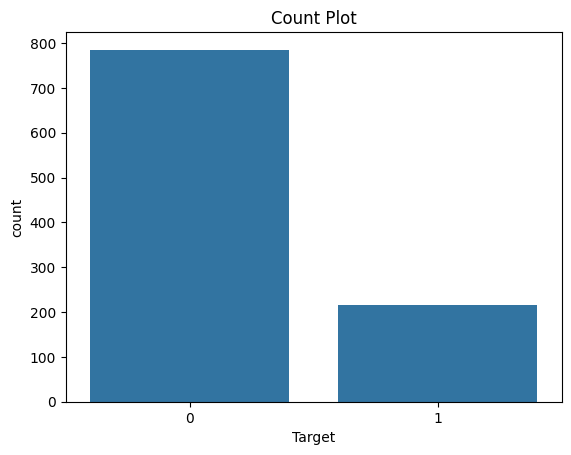

In [ ]:
plt.figure()
sns.countplot(x='Target', data=df)
plt.title("Count Plot")
plt.show()

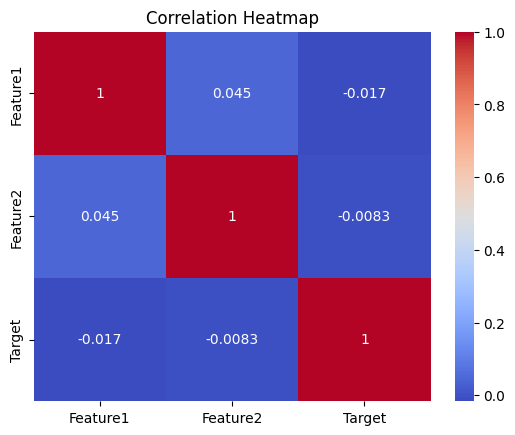

In [ ]:
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

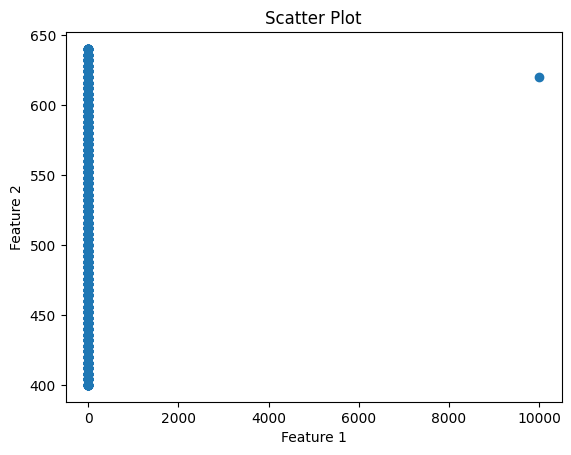

In [ ]:
plt.scatter(df['Feature1'], df['Feature2'])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot")
plt.show()

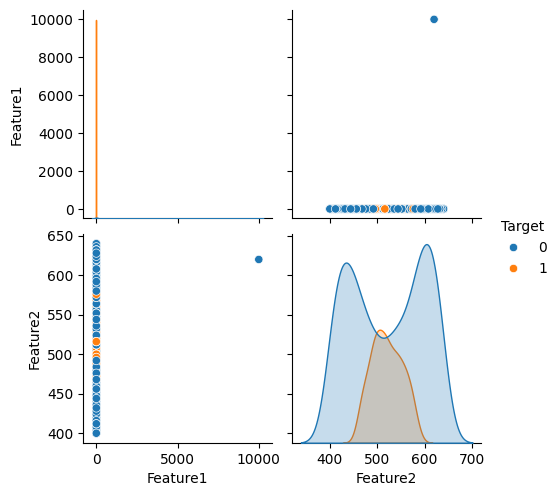

In [ ]:
sns.pairplot(df, hue='Target')
plt.show()

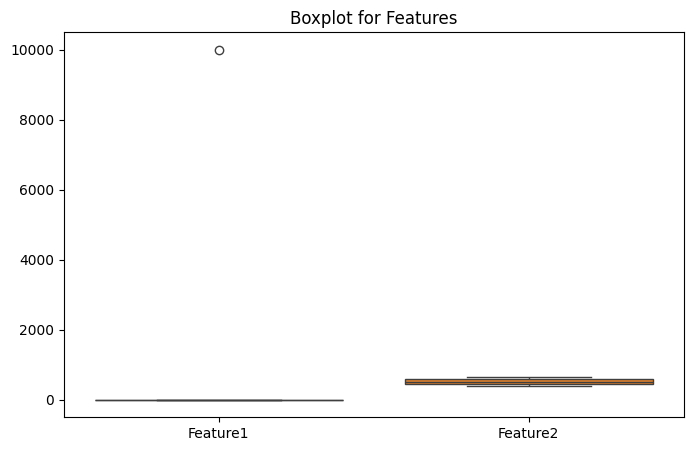

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Feature1', 'Feature2']])
plt.title("Boxplot for Features")
plt.show()

In [ ]:
X = df[['Feature1', 'Feature2']].values
y = df['Target'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.765

Confusion Matrix:
 [[153   0]
 [ 47   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87       153
           1       0.00      0.00      0.00        47

    accuracy                           0.77       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.59      0.77      0.66       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


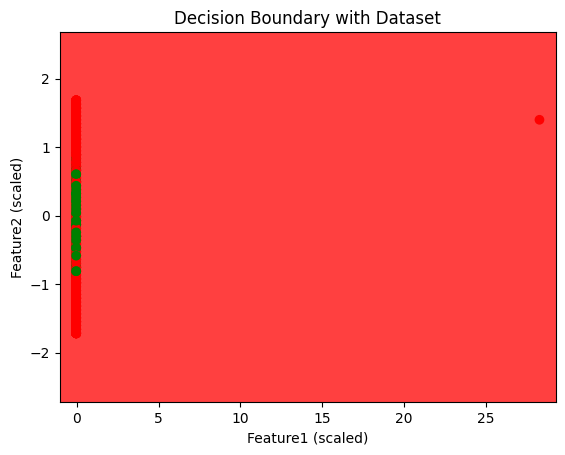

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Use training data
X_set, y_set = X_train, y_train

# Create mesh grid
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

# Predict over grid
Z = model.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

# Plot decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))

# Plot actual data points
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'green')))

# Labels and title
plt.title("Decision Boundary with Dataset")
plt.xlabel("Feature1 (scaled)")
plt.ylabel("Feature2 (scaled)")

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.935

Confusion Matrix:
 [[147   6]
 [  7  40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       153
           1       0.87      0.85      0.86        47

    accuracy                           0.94       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.93      0.94      0.93       200

